In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from collections import Counter
import math

In [2]:
from sklearn.model_selection import train_test_split

### Dataset of Telco customers.  Task is to predict customer churn. Target variable is 'Churn'

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(len(df))
df.head()

7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
df['TotalCharges']

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: object

Variable TotalCharges with null values

In [7]:
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()][['customerID', 'TotalCharges']]

,customerID,TotalCharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
print(df.dtypes)
df.head().T

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


Standartizing dataset columns format

In [9]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [10]:
str_col = df.columns[df.dtypes == 'str'].tolist()

for col in str_col:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [11]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

Converting target variable data type

In [12]:
df.churn = (df.churn == 'yes').astype(int)
df.churn.dtype

dtype('int64')

In [13]:
df.churn.value_counts()

churn
0    7043
Name: count, dtype: int64

EDA

In [14]:
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [15]:
df['churn'].value_counts()

churn
0    7043
Name: count, dtype: int64

Churn rate

In [16]:
df_churn_rate = df['churn'].mean()
df_churn_rate

np.float64(0.0)

Disbalanced dataset

In [17]:
categorical = df.columns[df.dtypes == 'str'].tolist()

categorical.remove('customerid')
categorical.append('seniorcitizen')
df[categorical].nunique()

ValueError: list.remove(x): x not in list

In [ ]:
numerical = df.columns[df.dtypes != 'str'].tolist()
numerical = list(filter(lambda x: x not in ['churn', 'seniorcitizen'], numerical))
df[numerical].nunique()

tenure              73
monthlycharges    1585
totalcharges      6531
dtype: int64

# Feature importance analysis

# Churn rate for categorical variables

In [ ]:
df[['gender', 'churn']][df.gender == 'female']

,gender,churn
0,female,0
4,female,1
5,female,1
7,female,0
8,female,1
...,...,...
7034,female,1
7036,female,0
7037,female,0
7039,female,0


In [ ]:
df[['gender', 'churn']][df.gender == 'male']

,gender,churn
1,male,0
2,male,1
3,male,0
6,male,0
9,male,0
...,...,...
7033,male,0
7035,male,0
7038,male,0
7041,male,1


In [ ]:
female_mean = df[df['gender'] == 'female']['churn'].mean()
female_mean

np.float64(0.26920871559633025)

In [ ]:
male_mean = df[df['gender'] == 'male']['churn'].mean()
male_mean

np.float64(0.2616033755274262)

gender is not segnificant predictor in customers churn

In [ ]:
print(f'churn rate with partner: {df[df['partner'] == 'yes']['churn'].mean()}')
print(f'churn rate without partner: {df[df['partner'] == 'no']['churn'].mean()}')
print(f'average churn rate in dataset: {df['churn'].mean()}')

churn rate with partner: 0.1966490299823633
churn rate without partner: 0.32957978577313923
average churn rate in dataset: 0.2653698707936959


partner can be segnificant predictor in customers churn

In [ ]:
print(f'diff in churn rate in female group: {female_mean - df_churn_rate}')
print(f'diff in churn rate in male group: {male_mean - df_churn_rate}')

print(f'risk ratio in female group: {female_mean / df_churn_rate }')
print(f'risk ratio in male group: {male_mean / df_churn_rate }')

diff in churn rate in female group: 0.003838844802634356
diff in churn rate in male group: -0.0037664952662697093
risk ratio in female group: 1.014466016021912
risk ratio in male group: 0.9858066205669676


In [ ]:
print(f'diff in churn rate in with partner group: {df[df['partner'] == 'yes']['churn'].mean() - df_churn_rate}')
print(f'diff in churn rate in without partner group: {df[df['partner'] == 'no']['churn'].mean() - df_churn_rate}')

print(f'risk ratio in with partner group: {df[df['partner'] == 'yes']['churn'].mean() / df_churn_rate }')
print(f'risk ratio in without partner group: {df[df['partner'] == 'no']['churn'].mean() / df_churn_rate }')

diff in churn rate in with partner group: -0.06872084081133259
diff in churn rate in without partner group: 0.06420991497944334
risk ratio in with partner group: 0.7410375164075894
risk ratio in without partner group: 1.241963847619165


In [ ]:
df_group = df.groupby(by='gender')['churn'].agg(['mean'])
df_group['diff'] = df_group['mean'] - df_churn_rate
df_group['risk'] = df_group['mean'] / df_churn_rate

In [ ]:
df_group

,mean,diff,risk
gender,,,
female,0.269209,0.003839,1.014466
male,0.261603,-0.003766,0.985807


### calculate target rate by category (mean encoding)

In [ ]:
categorical

['gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'seniorcitizen']

In [ ]:
for col in categorical:
    df_group = df.groupby(by=col)['churn'].agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - df_churn_rate
    df_group['risk'] = df_group['mean'] / df_churn_rate
    display(df_group)
    

,mean,count,diff,risk
gender,,,,
female,0.269209,3488,0.003839,1.014466
male,0.261603,3555,-0.003766,0.985807


,mean,count,diff,risk
partner,,,,
no,0.329580,3641,0.064210,1.241964
yes,0.196649,3402,-0.068721,0.741038


,mean,count,diff,risk
dependents,,,,
no,0.312791,4933,0.047422,1.178700
yes,0.154502,2110,-0.110868,0.582215


,mean,count,diff,risk
phoneservice,,,,
no,0.249267,682,-0.016103,0.939319
yes,0.267096,6361,0.001726,1.006506


,mean,count,diff,risk
multiplelines,,,,
no,0.250442,3390,-0.014927,0.943749
no_phone_service,0.249267,682,-0.016103,0.939319
yes,0.286099,2971,0.020729,1.078114


...

,mean,count,diff,risk
streamingmovies,,,,
no,0.336804,2785,0.071434,1.269188
no_internet_service,0.074050,1526,-0.191320,0.279044
yes,0.299414,2732,0.034044,1.128291


,mean,count,diff,risk
contract,,,,
month-to-month,0.427097,3875,0.161727,1.609440
one_year,0.112695,1473,-0.152675,0.424672
two_year,0.028319,1695,-0.237051,0.106714


,mean,count,diff,risk
paperlessbilling,,,,
no,0.163301,2872,-0.102069,0.615371
yes,0.335651,4171,0.070281,1.264842


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.167098,1544,-0.098271,0.629681
credit_card_(automatic),0.152431,1522,-0.112939,0.574410
electronic_check,0.452854,2365,0.187484,1.706502
mailed_check,0.191067,1612,-0.074303,0.720003


,mean,count,diff,risk
seniorcitizen,,,,
0,0.236062,5901,-0.029308,0.889557
1,0.416813,1142,0.151443,1.570686


Выделить сегменты повышенного риска, чтобы понять какие категории пользователей наиболее подвержены уходу

# Calculating mutual information for categorical variables

In [ ]:
from sklearn.metrics import mutual_info_score

In [ ]:
MI = {}
for col in categorical:
    MI[col] = (mutual_info_score(df[col].astype('category').cat.codes, df['churn']))
sorted(MI.items(), key= lambda x: x[1], reverse=True)

[('contract', 0.09845305342598942),
 ('onlinesecurity', 0.06467728245735829),
 ('techsupport', 0.06302103606897548),
 ('internetservice', 0.05557418477268879),
 ('onlinebackup', 0.04679232253922637),
 ('paymentmethod', 0.044518668630902994),
 ('deviceprotection', 0.04391690927485155),
 ('streamingmovies', 0.03200094959522297),
 ('streamingtv', 0.031907975162527094),
 ('paperlessbilling', 0.019194399646111526),
 ('dependents', 0.014467261139424592),
 ('partner', 0.011453657253317984),
 ('seniorcitizen', 0.010577263953987642),
 ('multiplelines', 0.0008012658524292199),
 ('phoneservice', 7.215949186982484e-05),
 ('gender', 3.7082914405128786e-05)]

# Matual information function from scratch with using Shannon entropy function

In [ ]:
def shennon_entropy(x):
    counts = Counter(x)
    p = [counts[i] / len(x) for i in counts.keys()]
    H = -sum([i * math.log(i, 2) for i in p])
    return H

def mutual_information(x, y):
    Hx = shennon_entropy(x)
    Hy = shennon_entropy(y)
    Hxy = shennon_entropy(list(zip(x, y)))
    return Hx + Hy - Hxy

In [ ]:
shennon_entropy(df['churn'])

0.8347419473972113

# Comparison of sklearn and custom mutual information functions

In [ ]:
MI_cust = {}
for col in categorical:
    MI_cust[col] = (mutual_information(df[col].astype('category').cat.codes, df['churn']))
sorted(MI_cust.items(), key= lambda x: x[1], reverse=True)

[('contract', 0.14203773193805125),
 ('onlinesecurity', 0.0933095946594058),
 ('techsupport', 0.09092013620839579),
 ('internetservice', 0.08017660077300492),
 ('onlinebackup', 0.06750705167902016),
 ('paymentmethod', 0.06422686246078335),
 ('deviceprotection', 0.06335870722199921),
 ('streamingmovies', 0.04616761128476643),
 ('streamingtv', 0.04603347753178655),
 ('paperlessbilling', 0.027691665182286496),
 ('dependents', 0.02087184590109259),
 ('partner', 0.0165241345194036),
 ('seniorcitizen', 0.015259766252591511),
 ('multiplelines', 0.0011559822717330803),
 ('phoneservice', 0.0001041041410740906),
 ('gender', 5.34993367133918e-05)]

Both functions give the same results

We see that variablels with the highest mutual information are 'contract', 'onlinesecurity','techsupport' and'internetservice'

Some of variables shows close to zero mutual information, so we can do not consider them in future analysis

# Pearson correlation coefficient for numerical variables

In [ ]:
numerical

['tenure', 'monthlycharges', 'totalcharges']

In [ ]:
df[numerical].corrwith(df['churn'])

tenure           -0.352229
monthlycharges    0.193356
totalcharges     -0.198324
dtype: float64

In [ ]:
sorted(df['tenure'].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.i

In [ ]:
# churn rate for ranges of tenure
churn_rate_0_2 = df[df['tenure'].isin([0,1,2])]['churn'].mean()
print(churn_rate_0_2)

churn_rate_3_15 = df[df['tenure'].isin(range(3,16))]['churn'].mean()
print(churn_rate_3_15)

churn_rate_16_end = df[df['tenure'] > 15]['churn'].mean()
print(churn_rate_16_end)

0.5835266821345708
0.39365671641791045
0.16028865077629564


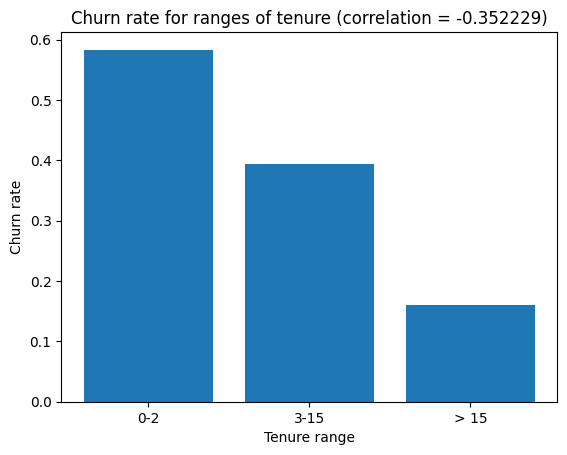

In [ ]:
plt.bar(['0-2', '3-15', '> 15'], [churn_rate_0_2, churn_rate_3_15, churn_rate_16_end])
plt.title('Churn rate for ranges of tenure (correlation = -0.352229)')
plt.xlabel('Tenure range')
plt.ylabel('Churn rate')
plt.show()

In [ ]:
sorted(df['monthlycharges'].unique())

[np.float64(18.25),
 np.float64(18.4),
 np.float64(18.55),
 np.float64(18.7),
 np.float64(18.75),
 np.float64(18.8),
 np.float64(18.85),
 np.float64(18.9),
 np.float64(18.95),
 np.float64(19.0),
 np.float64(19.05),
 np.float64(19.1),
 np.float64(19.15),
 np.float64(19.2),
 np.float64(19.25),
 np.float64(19.3),
 np.float64(19.35),
 np.float64(19.4),
 np.float64(19.45),
 np.float64(19.5),
 np.float64(19.55),
 np.float64(19.6),
 np.float64(19.65),
 np.float64(19.7),
 np.float64(19.75),
 np.float64(19.8),
 np.float64(19.85),
 np.float64(19.9),
 np.float64(19.95),
 np.float64(20.0),
 np.float64(20.05),
 np.float64(20.1),
 np.float64(20.15),
 np.float64(20.2),
 np.float64(20.25),
 np.float64(20.3),
 np.float64(20.35),
 np.float64(20.4),
 np.float64(20.45),
 np.float64(20.5),
 np.float64(20.55),
 np.float64(20.6),
 np.float64(20.65),
 np.float64(20.7),
 np.float64(20.75),
 np.float64(20.8),
 np.float64(20.85),
 np.float64(20.9),
 np.float64(20.95),
 np.float64(21.0),
 np.float64(21.05),
 np.f

In [ ]:
# churn rate for ranges of monthly charges
churn_rate_0_50 = df[df['monthlycharges'].isin(range(0,20))]['churn'].mean()
print(churn_rate_0_50)

churn_rate_51_100 = df[df['monthlycharges'].isin(range(21,50))]['churn'].mean()
print(churn_rate_51_100)

churn_rate_101_end = df[df['monthlycharges'] > 50]['churn'].mean()
print(churn_rate_101_end)

0.14285714285714285
0.18055555555555555
0.3178752107925801


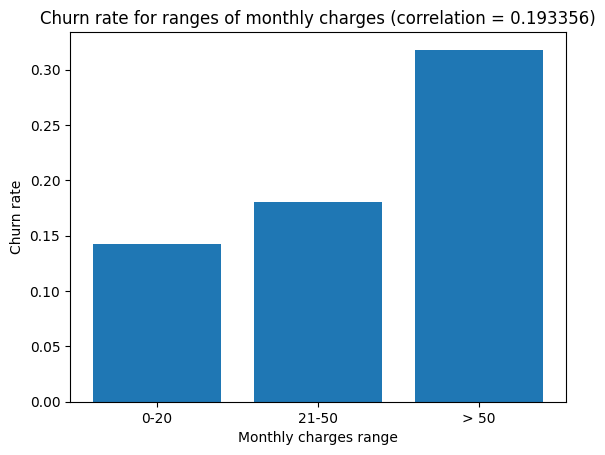

In [ ]:
plt.bar(['0-20', '21-50', '> 50'], [churn_rate_0_50, churn_rate_51_100, churn_rate_101_end])
plt.title('Churn rate for ranges of monthly charges (correlation = 0.193356)')
plt.xlabel('Monthly charges range')
plt.ylabel('Churn rate')
plt.show()

## Conclusions:

tenure corr = -0.352229:

- customers with longer tenure are not likely to churn
- customers with tenure 0-2 (churn rate ~0.61) are more likely to churn than customers with tenure 3-15 (churn rate ~0.40)
- customers with tenure > 15 have lower churn rate (~0.17)


monthlycharges corr = 0.193356:
- customers with higher monthly charges are more likely to churn
- customers with monthly charges 0-20 (churn rate ~0.14) are not more likely to churn than customers with monthly charges 21-50 (churn rate ~0.18)
- customers with monthly charges > 50 have higher churn rate (~0.32)

totalcharges corr = -0.198324:
- customers with higher total charges are not more likely to churn
- total charges can be depend on tenure because customers with longer tenure have higher total charges

Pearson correlation function from sctratch and comparison with sklearn results

In [ ]:
def pearson_correlation(x, y):
    x_mean = x.mean()
    y_mean = y.mean()

    x_std = math.sqrt(np.sum((x - x_mean)**2))
    y_std = math.sqrt(np.sum((y - y_mean)**2))

    cov = np.sum((x - x_mean)*(y - y_mean))

    return cov / (x_std * y_std)


In [ ]:
print(f'corr from scratch for teanure and churn: {pearson_correlation(df['tenure'], df['churn'])}')
print(f'corr from scratch for monthlycharges and churn: {pearson_correlation(df['monthlycharges'], df['churn'])}')
print(f'corr from scratch for totalcharges and churn: {pearson_correlation(df['totalcharges'], df['churn'])}')

corr from scratch for teanure and churn: -0.35222867011307796
corr from scratch for monthlycharges and churn: 0.19335642223784705
corr from scratch for totalcharges and churn: -0.19832426260399555


We can see that Pearson correlation function from scratch and sklearn results are the same

# One Hot Encoding with DictVectorizer

In [ ]:
# categorical features with high MI
sorted(MI.items(), key = lambda x: x[1], reverse=True)

[('contract', 0.09845305342598942),
 ('onlinesecurity', 0.06467728245735829),
 ('techsupport', 0.06302103606897548),
 ('internetservice', 0.05557418477268879),
 ('onlinebackup', 0.04679232253922637),
 ('paymentmethod', 0.044518668630902994),
 ('deviceprotection', 0.04391690927485155),
 ('streamingmovies', 0.03200094959522297),
 ('streamingtv', 0.031907975162527094),
 ('paperlessbilling', 0.019194399646111526),
 ('dependents', 0.014467261139424592),
 ('partner', 0.011453657253317984),
 ('seniorcitizen', 0.010577263953987642),
 ('multiplelines', 0.0008012658524292199),
 ('phoneservice', 7.215949186982484e-05),
 ('gender', 3.7082914405128786e-05)]

In [ ]:
from sklearn.feature_extraction import DictVectorizer

In [ ]:
full_dict = df[categorical + numerical].to_dict(orient='records')
full_dict[0]

{'gender': 'female',
 'partner': 'yes',
 'dependents': 'no',
 'phoneservice': 'no',
 'multiplelines': 'no_phone_service',
 'internetservice': 'dsl',
 'onlinesecurity': 'no',
 'onlinebackup': 'yes',
 'deviceprotection': 'no',
 'techsupport': 'no',
 'streamingtv': 'no',
 'streamingmovies': 'no',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'seniorcitizen': 0,
 'tenure': 1,
 'monthlycharges': 29.85,
 'totalcharges': 29.85}

In [ ]:
dv = DictVectorizer(sparse=False)
dv.fit(full_dict)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [ ]:
X = dv.transform(full_dict)
print(X.shape)

(7043, 45)


In [ ]:
X[0]

array([ 1.  ,  0.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  ,
        0.  ,  1.  ,  0.  ,  0.  , 29.85,  0.  ,  1.  ,  0.  ,  0.  ,
        0.  ,  1.  ,  1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  ,  1.  ,
        0.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  ,  0.  ,
        0.  ,  1.  ,  0.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  , 29.85])

In [ ]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [ ]:
fin_df = pd.DataFrame(X, columns=dv.get_feature_names_out())
fin_df.head()

,contract=month-to-month,contract=one_year,contract=two_year,dependents=no,dependents=yes,deviceprotection=no,deviceprotection=no_internet_service,deviceprotection=yes,gender=female,gender=male,...,streamingmovies=no_internet_service,streamingmovies=yes,streamingtv=no,streamingtv=no_internet_service,streamingtv=yes,techsupport=no,techsupport=no_internet_service,techsupport=yes,tenure,totalcharges
0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,29.85
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,34.0,1889.50
2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,108.15
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,45.0,1840.75
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,151.65


In [ ]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,0
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.50,0
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,1
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,0
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,1


# Logistic Regression

In [ ]:
print(df['churn'].value_counts())
print(df['churn'].value_counts(normalize=True))

churn
0    5174
1    1869
Name: count, dtype: int64
churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


Class imbalance in target

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [ ]:
y = df['churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)

In [ ]:
y_pred_proba # 0 1

array([[0.94917386, 0.05082614],
       [0.31297307, 0.68702693],
       [0.94288465, 0.05711535],
       ...,
       [0.8415553 , 0.1584447 ],
       [0.99483762, 0.00516238],
       [0.99299053, 0.00700947]], shape=(1409, 2))

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [ ]:
y_pr_pred = y_pred_proba >= 0.5
y_pr_pred[:,1].astype('int')

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

# Model quality control

In [ ]:
(y_test == y_pr_pred[:,1].astype('int')).mean()

np.float64(0.801277501774308)

Reability of model = 0.8

In [ ]:
coeff_model = dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))
print(model.intercept_[0])
print(coeff_model)

-0.16288538547970194
{'contract=month-to-month': np.float64(0.59), 'contract=one_year': np.float64(-0.16), 'contract=two_year': np.float64(-0.593), 'dependents=no': np.float64(0.035), 'dependents=yes': np.float64(-0.198), 'deviceprotection=no': np.float64(0.008), 'deviceprotection=no_internet_service': np.float64(-0.124), 'deviceprotection=yes': np.float64(-0.047), 'gender=female': np.float64(-0.093), 'gender=male': np.float64(-0.07), 'internetservice=dsl': np.float64(-0.402), 'internetservice=fiber_optic': np.float64(0.363), 'internetservice=no': np.float64(-0.124), 'monthlycharges': np.float64(0.003), 'multiplelines=no': np.float64(-0.257), 'multiplelines=no_phone_service': np.float64(0.083), 'multiplelines=yes': np.float64(0.011), 'onlinebackup=no': np.float64(0.075), 'onlinebackup=no_internet_service': np.float64(-0.124), 'onlinebackup=yes': np.float64(-0.114), 'onlinesecurity=no': np.float64(0.203), 'onlinesecurity=no_internet_service': np.float64(-0.124), 'onlinesecurity=yes': np

# доделать
Precision, Recall, F1-меру, ROC-AUC, визуализацию Confusion Matrix и ROC Curve, а также кросс-валидацию для более строгой проверки модели